In [1]:
#Shreyan Juvvadi, Sarah Dweik, Likai Yang, and Hiu Yung Wong, 3D Simulation of Flip Chip Qubit System with Intermediate Coupling Layer, 2026 IEEE International Conference on Quantum Computing and Engineering (QCE).
Created by Sarah Dweik
import numpy as np
import matplotlib.pyplot as plt
!pip install qutip
import qutip as qt

In [10]:
# --- Physical Constants ---
e = 1.602176634e-19
h = 6.62607015e-34

# --- Energy Calculation Function ---
def calculate_qubit_energies(C_sigma_fF, f_q_ghz):
    """
    Calculates Ec and Ej for a transmon qubit.
    C_sigma_fF: Total capacitance in Femtofarads (fF)
    f_q_ghz: Qubit frequency in Gigahertz (GHz)
    """
    C_sigma = C_sigma_fF * 1e-15
    
    # 1. Calculate Charging Energy Ec (in Joules then GHz)
    E_c_joules = (e**2) / (2 * C_sigma)
    E_c_ghz = E_c_joules / h / 1e9
    
    # 2. Calculate Josephson Energy Ej (in Joules then GHz)
    # Solve f_q = (sqrt(8*Ej*Ec) - Ec) / h  for Ej
    f_q_hz = f_q_ghz * 1e9
    numerator = (f_q_hz * h + E_c_joules)**2
    denominator = 8 * E_c_joules
    E_j_joules = numerator / denominator
    E_j_ghz = E_j_joules / h / 1e9
    inductance = (h/2/e)**2/(2*3.14)**2/E_j_joules*1e9
    print(inductance)
    
    return {
        "E_c_ghz": E_c_ghz,
        "E_j_ghz": E_j_ghz,
        "anharmonicity_ghz": -E_c_ghz,
        "Inductance": inductance
    }

# --- 1. Calculate Hardware Parameters ---
# Both qubits share C_sigma = 94.4 fF
#C_sig = 88.9  # single plate effective ground to cap by cutting resonator, not using equation
C_sig = 89.2  # with middle cap effective ground to cap by cutting resonator, not using equation


# Qubit 1 hardware (5.64 GHz)
props1 = calculate_qubit_energies(C_sig, 6.19)
EC1, EJ1, alpha1, L1 = props1["E_c_ghz"], props1["E_j_ghz"], props1["anharmonicity_ghz"], props1["Inductance"]

# Qubit 2 hardware (6.31 GHz)
props2 = calculate_qubit_energies(C_sig, 6.63)
EC2, EJ2, alpha2, L2 = props2["E_c_ghz"], props2["E_j_ghz"], props2["anharmonicity_ghz"], props2["Inductance"]

print(f"Qubit 1 Hardware: EC = {EC1:.4f} GHz, EJ = {EJ1:.4f} GHz, alpha = {alpha1:.4f} GHz, L = {L1:.4f} nH")
print(f"Qubit 2 Hardware: EC = {EC2:.4f} GHz, EJ = {EJ2:.4f} GHz, alpha = {alpha2:.4f} GHz, L = {L2:.4f} nH")

# --- 2. Simulation Frequencies (Both at 6.31 GHz) ---
f_sim_GHz = 6.62
w1 = f_sim_GHz * 2 * np.pi 
w2 = f_sim_GHz * 2 * np.pi

# --- 3. Interaction Logic ---
def calculate_params(Cc_fF):
    Cc = Cc_fF * 1e-15
    # Charging energy of the coupling capacitor in GHz
    ECc = (e**2 / (2 * Cc)) / h / 1e9
    # J in GHz using the calculated hardware EJ and EC
    J = (2 * (EC1 * EC2) / ECc) * (EJ1 / (2 * EC1) * EJ2 / (2 * EC2))**0.25
    # J_rad in rad/ns
    J_rad = J * 2 * np.pi
    return J, J_rad

# Baseline for ideal gate time
Cc_baseline = 35
J_base, J_rad_base = calculate_params(Cc_baseline)
print(J_base)
tau_ideal =  np.pi / (4 * J_rad_base) 
print(tau_ideal)
# --- 4. QuTiP Setup ---
si  = qt.qeye(2)
sz1 = qt.tensor(qt.sigmaz(), si)
sz2 = qt.tensor(si, qt.sigmaz())
sm1 = qt.tensor(qt.destroy(2), si)
sm2 = qt.tensor(si, qt.destroy(2))
print(qt.destroy(2))
# Hamiltonian in rad/ns
H_qubits = -0.5 * w1 * sz1 - 0.5 * w2 * sz2
H_int_op = sm1.dag() * sm2 + sm1 * sm2.dag()

# Initial and Target States
psi0 = qt.tensor(qt.basis(2, 1), qt.basis(2, 0))
H_ideal = H_qubits + J_rad_base * H_int_op
target_psi = (-1j * H_ideal * tau_ideal).expm() * psi0

6.924451730691226
6.063111222954909
Qubit 1 Hardware: EC = 0.2172 GHz, EJ = 23.6304 GHz, alpha = -0.2172 GHz, L = 6.9245 nH
Qubit 2 Hardware: EC = 0.2172 GHz, EJ = 26.9874 GHz, alpha = -0.2172 GHz, L = 6.0631 nH
1.2994539438962451
0.0961942518910702
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0. 1.]
 [0. 0.]]


<>:31: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:31: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\012738063\AppData\Local\Temp\ipykernel_18448\2417610548.py:31: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  f'{labels[i]} $C_c$={Cc}fF, $J/2\pi$={J_val*1e3:.1f}MHz, F={fid_val:.4f}',


1.2994539438962451
0.43067616426275546
0.28587986765717394


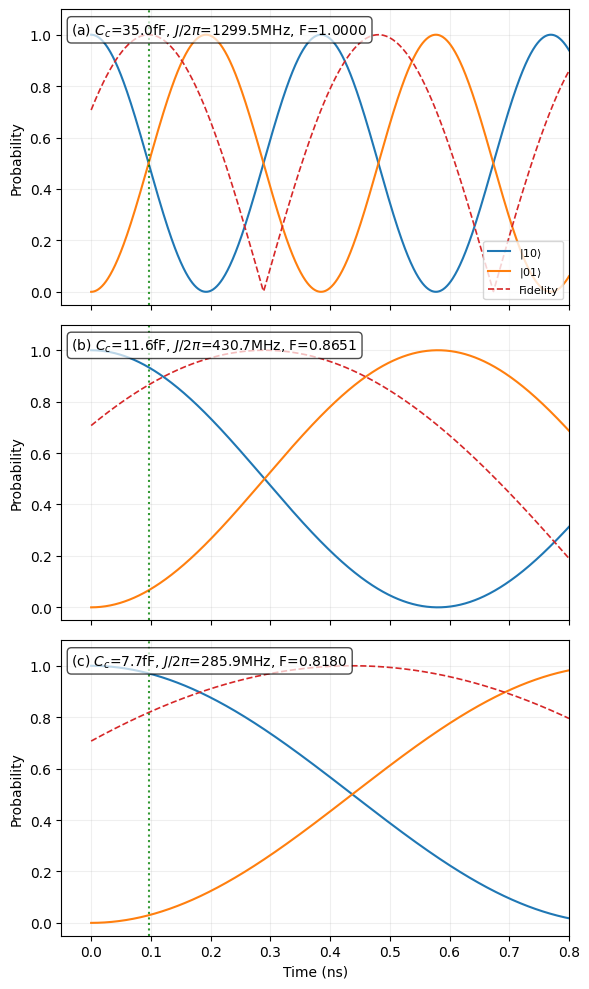

In [9]:
# --- 5. Simulation and Plotting ---
Cc_values = [35.0, 11.6, 7.7]
labels = ['(a)', '(b)', '(c)']
tlist = np.linspace(0, 0.8, 1000)

fig, axes = plt.subplots(3, 1, figsize=(6, 10), sharex=True)
proj10 = qt.tensor(qt.basis(2, 1), qt.basis(2, 0)).proj()
proj01 = qt.tensor(qt.basis(2, 0), qt.basis(2, 1)).proj()

for i, Cc in enumerate(Cc_values):
    J_val, J_rad_current = calculate_params(Cc)
    print(J_val)
    H_actual = H_qubits + J_rad_current * H_int_op

    result = qt.mesolve(H_actual, psi0, tlist, c_ops=[], e_ops=[])

    p10 = [qt.expect(proj10, s) for s in result.states]
    p01 = [qt.expect(proj01, s) for s in result.states]
    fids = [qt.fidelity(s, target_psi) for s in result.states]

    idx_gate = np.argmin(np.abs(tlist - tau_ideal))
    fid_val = fids[idx_gate]

    ax = axes[i]
    ax.plot(tlist, p10, label=r'$|10\rangle$', lw=1.5)
    ax.plot(tlist, p01, label=r'$|01\rangle$', lw=1.5)
    ax.plot(tlist, fids, label='Fidelity', color='tab:red', linestyle='--', lw=1.2)
    ax.axvline(tau_ideal, color='green', linestyle=':', alpha=0.8)

    ax.text(0.02, 0.96, 
            f'{labels[i]} $C_c$={Cc}fF, $J/2\pi$={J_val*1e3:.1f}MHz, F={fid_val:.4f}',
            transform=ax.transAxes, va='top', bbox=dict(boxstyle='round', fc='white', alpha=0.7))

    ax.set_ylabel("Probability")
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlim(-0.05, 0.8)
    ax.grid(True, alpha=0.2)
    if i == 0: ax.legend(loc='lower right', fontsize=8)

axes[-1].set_xlabel("Time (ns)")
plt.tight_layout()
plt.show()

fig.savefig("Fidelity_Comparision_Capacitive_coupling_8.png", dpi=300, bbox_inches="tight")